In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from mphsweepkit.plot_data import DataPlot, PlotSettings, PlotTextOverrides
from mphsweepkit.tex import *

In [3]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("result_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 3) Access metadata
y_col = dp.output_columns()[0]
print(f"\nSelected output column: {y_col}")
print("Label:", dp.get_label(y_col))
print("Unit:", dp.get_unit(y_col))
print("Axis label:", dp.format_axis_label(y_col))

# 4) Access combined dataframe
dp.combined_df.head()

Input shape: (158, 8)
Output shape: (158, 3)
Combined shape: (158, 11)

Input columns: ['hor_slit', 'vert_slit', 'w', 'l_r', 'a_e', 'matsw.comp1.core', 'b_mean', 'freq']
Output columns: ['p_loss', 'p_mag', 'p_el']

Selected output column: p_loss
Label: p_loss
Unit: W /m^3
Axis label: p_loss [W /m^3]


,hor_slit,vert_slit,w,l_r,a_e,matsw.comp1.core,b_mean,freq,p_loss,p_mag,p_el
name,,,,,,,,,,,
unit,um,um,mm,mm,mm,NaN,mT,kHz,W /m^3,W /m^3,W /m^3
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Frequency Sweep,post-processing,post-processing,post-processing
0,0.0,0.0,10.0,0.0,5.0,2.0,25.0,100.0,1138.7931745362628,1016.234898506517,122.558276029742
1,0.0,0.0,10.0,0.0,5.0,2.0,25.0,200.0,3233.052525791783,2542.864479035651,690.1880467561253
2,0.0,0.0,10.0,0.0,5.0,2.0,25.0,300.0,6623.256480100142,4630.24333910561,1993.0131409945309


Exemplary Visualization of average loss density in dependence of the geometry with the **DataPlot** class

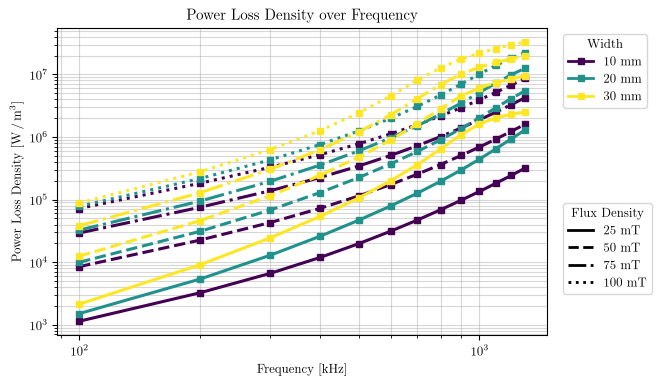

In [4]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 10 / 2.54))  

custom_settings = PlotSettings(
    x_scale="log",
    y_scale="log",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True
)

dp.y_over_x_with_color_and_style(
    ax,
    y_col="p_loss",
    x_col="freq",
    color_col="w",
    style_col="b_mean",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Power Loss Density",
        y_unit="$\\mathrm{W} \\, / \\, \\mathrm{m}^3$",
        color_label="Width",
        color_unit="mm",
        style_label="Flux Density",
        style_unit="mT",
    ),
)

plt.show()

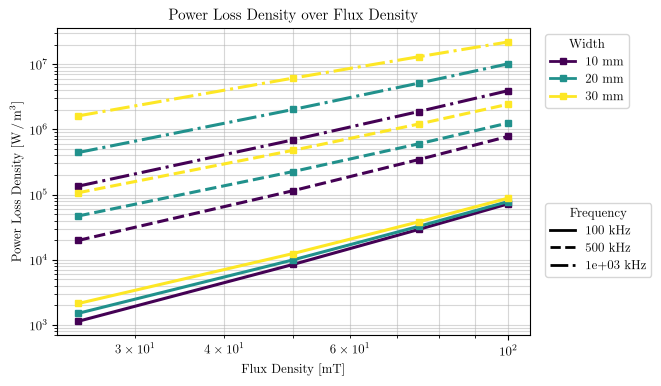

In [5]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 10 / 2.54))  


custom_settings = PlotSettings(
    x_scale="log",
    y_scale="log",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True
)

dp.y_over_x_with_color_and_style(
    ax,
    y_col="p_loss",
    x_col="b_mean",
    color_col="w",
    style_col="freq",
    filters={"freq": [100, 500, 1000]},
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Flux Density",
        x_unit="mT",
        y_label="Power Loss Density",
        y_unit="$\\mathrm{W} \\, / \\, \\mathrm{m}^3$",
        color_label="Width",
        color_unit="mm",
        style_label="Frequency",
        style_unit="kHz",
    ),
)

plt.show()